In [187]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [188]:
import os

DATA_PATH = "../data/raw"

hanoi = pd.read_csv(os.path.join(DATA_PATH, "hanoi_hourly.csv"))
danang = pd.read_csv(os.path.join(DATA_PATH, "danang_hourly.csv"))
hcm = pd.read_csv(os.path.join(DATA_PATH, "hcm_hourly.csv"))

### Data exploration


In [189]:
print(f"Dataset shape: {hanoi.shape}")
hanoi.info()
hanoi.describe(include='all')

Dataset shape: (10680, 6)
<class 'pandas.DataFrame'>
RangeIndex: 10680 entries, 0 to 10679
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   datetime     10680 non-null  str    
 1   temperature  10680 non-null  float64
 2   humidity     10680 non-null  int64  
 3   rain         10680 non-null  float64
 4   wind         10680 non-null  float64
 5   pressure     10680 non-null  float64
dtypes: float64(4), int64(1), str(1)
memory usage: 500.8 KB


,datetime,temperature,humidity,rain,wind,pressure
count,10680,10680.000000,10680.000000,10680.000000,10680.000000,10680.00000
unique,10680,NaN,NaN,NaN,NaN,NaN
top,2025-01-01T00:00,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN
mean,NaN,23.255693,80.127809,0.243549,8.388464,1009.56779
std,NaN,5.372166,14.254659,1.066522,4.372102,7.50203
min,NaN,8.800000,23.000000,0.000000,0.000000,985.80000
25%,NaN,19.200000,71.000000,0.000000,5.100000,1003.60000
50%,NaN,23.800000,83.000000,0.000000,8.000000,1009.70000
75%,NaN,27.200000,92.000000,0.000000,11.200000,1015.50000


### mising value 


In [190]:
print("\nMissing values:")
print("\n Ha Noi:")
print(hanoi.isnull().sum())
print("\nDa Nang:")
print(danang.isnull().sum())
print("\nHCM:")
print(hcm.isnull().sum())



Missing values:

 Ha Noi:
datetime       0
temperature    0
humidity       0
rain           0
wind           0
pressure       0
dtype: int64

Da Nang:
datetime       0
temperature    0
humidity       0
rain           0
wind           0
pressure       0
dtype: int64

HCM:
datetime       0
temperature    0
humidity       0
rain           0
wind           0
pressure       0
dtype: int64


## Preprocessing Data

In [191]:
hanoi['city'] = 'hanoi'
danang['city'] = 'danang'
hcm['city'] = 'hcm'
# gộp
df = pd.concat([hanoi, danang, hcm])


In [192]:
print(df['city'].value_counts())

city
hanoi     10680
danang    10680
hcm       10680
Name: count, dtype: int64


<class 'pandas.DataFrame'>
Index: 32040 entries, 0 to 10679
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   datetime     32040 non-null  str    
 1   temperature  32040 non-null  float64
 2   humidity     32040 non-null  int64  
 3   rain         32040 non-null  float64
 4   wind         32040 non-null  float64
 5   pressure     32040 non-null  float64
 6   city         32040 non-null  str    
dtypes: float64(4), int64(1), str(2)
memory usage: 2.0 MB
None


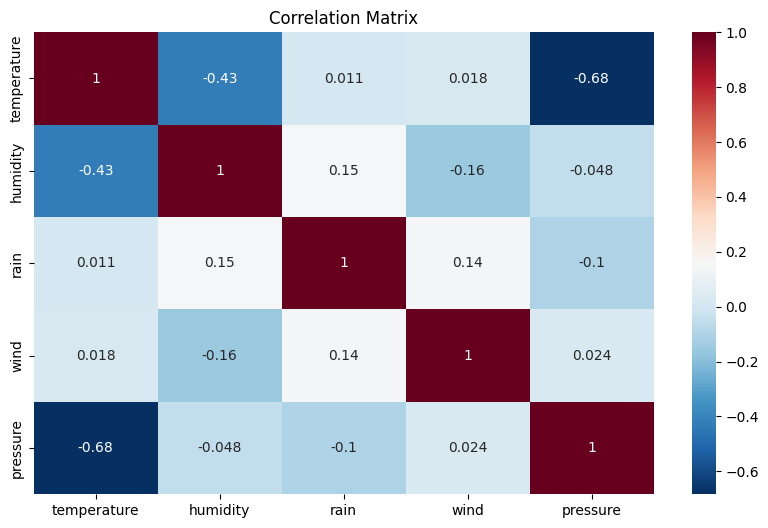

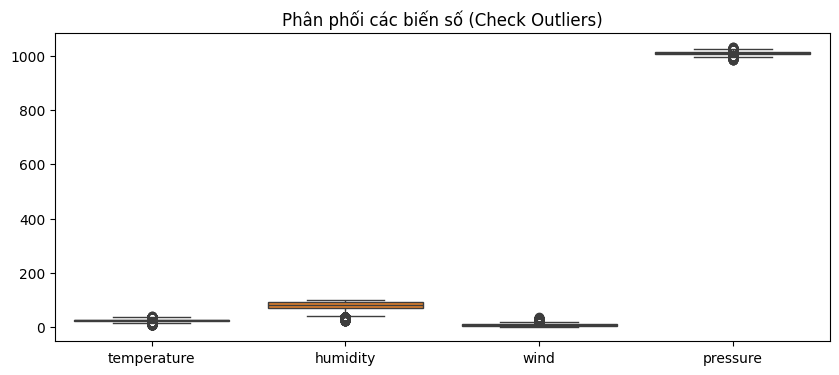

In [193]:
# Kiểm tra thông tin tổng quát
print(df.info())

# Vẽ ma trận tương quan
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='RdBu_r')
plt.title("Correlation Matrix")
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(data=df[['temperature', 'humidity', 'wind', 'pressure']])
plt.title("Phân phối các biến số (Check Outliers)")
plt.show()

In [194]:
def remove_outliers_iqr(df, columns):
    df_final = df.copy()
    for col in columns:
        Q1 = df_final[col].quantile(0.25)
        Q3 = df_final[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        # Thay vì xóa, ta clip (giới hạn) để không làm mất mốc thời gian
        df_final[col] = df_final[col].clip(lower, upper)
    return df_final

df_cleaned = remove_outliers_iqr(df, ['temperature', 'humidity', 'pressure'])
print("Đã xử lý Outliers xong.")
df_cleaned.to_csv("../data/processed/data.csv", index=False)

Đã xử lý Outliers xong.


Feature Egineering

In [195]:
def create_features(df):
    df = df.copy()
    df['datetime'] = pd.to_datetime(df['datetime']) 
    df = df.sort_values(['city', 'datetime'])

    df['hour'] = df['datetime'].dt.hour
    df['dayofweek'] = df['datetime'].dt.dayofweek
    df['month'] = df['datetime'].dt.month

    # Lag
    df['rain_lag1'] = df.groupby('city')['rain'].shift(1) 
    df['rain_lag3'] = df.groupby('city')['rain'].shift(3)
    df['rain_lag24'] = df.groupby('city')['rain'].shift(24)

    df['rain_roll3'] = df.groupby('city')['rain'] \
        .shift(1).rolling(3).mean().reset_index(0, drop=True)

    df['rain_roll24'] = df.groupby('city')['rain'] \
        .shift(1).rolling(24).mean().reset_index(0, drop=True)
    df['target'] = df.groupby('city')['rain'].shift(-1)

    # Encode
    df = pd.get_dummies(df, columns=['city'], drop_first=True)

    return df.dropna()

df_final = create_features(df_cleaned)
df_final.head()

,datetime,temperature,humidity,rain,wind,pressure,hour,dayofweek,month,rain_lag1,rain_lag3,rain_lag24,rain_roll3,rain_roll24,target,city_hanoi,city_hcm
24,2025-01-02 00:00:00,20.5,93.0,0.0,6.0,1014.9,0,3,1,0.0,0.0,0.0,0.0,0.0,0.0,False,False
25,2025-01-02 01:00:00,20.5,93.0,0.0,4.8,1014.7,1,3,1,0.0,0.0,0.0,0.0,0.0,0.0,False,False
26,2025-01-02 02:00:00,20.5,93.0,0.0,3.8,1014.0,2,3,1,0.0,0.0,0.0,0.0,0.0,0.0,False,False
27,2025-01-02 03:00:00,20.5,93.0,0.0,4.3,1013.9,3,3,1,0.0,0.0,0.0,0.0,0.0,0.0,False,False
28,2025-01-02 04:00:00,20.5,92.0,0.0,5.9,1014.0,4,3,1,0.0,0.0,0.0,0.0,0.0,0.0,False,False


Split train val test

In [196]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
def split_and_scale(df_final):
    df_final = df_final.sort_values('datetime').reset_index(drop=True)

    features = [
        'temperature', 'humidity', 'wind', 'pressure',
        'hour', 'dayofweek', 'month',
        'rain_lag1', 'rain_lag3', 'rain_lag24',
        'rain_roll3', 'rain_roll24'
    ] + [col for col in df_final.columns if 'city_' in col]

    target = 'rain' 

    train_size = int(len(df_final) * 0.7)
    val_size = int(len(df_final) * 0.15)

    train = df_final.iloc[:train_size]
    val = df_final.iloc[train_size:train_size+val_size]
    test = df_final.iloc[train_size+val_size:]

    X_train, y_train = train[features], train[target]
    X_val, y_val = val[features], val[target]
    X_test, y_test = test[features], test[target]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    return (X_train_scaled, y_train), (X_val_scaled, y_val), (X_test_scaled, y_test), scaler
(X_train, y_train), (X_val, y_val), (X_test, y_test), scaler = split_and_scale(df_final)
print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Val:   {X_val.shape}")
print(f"Kích thước tập Test:  {X_test.shape}")

Kích thước tập Train: (22375, 14)
Kích thước tập Val:   (4794, 14)
Kích thước tập Test:  (4796, 14)


visualize

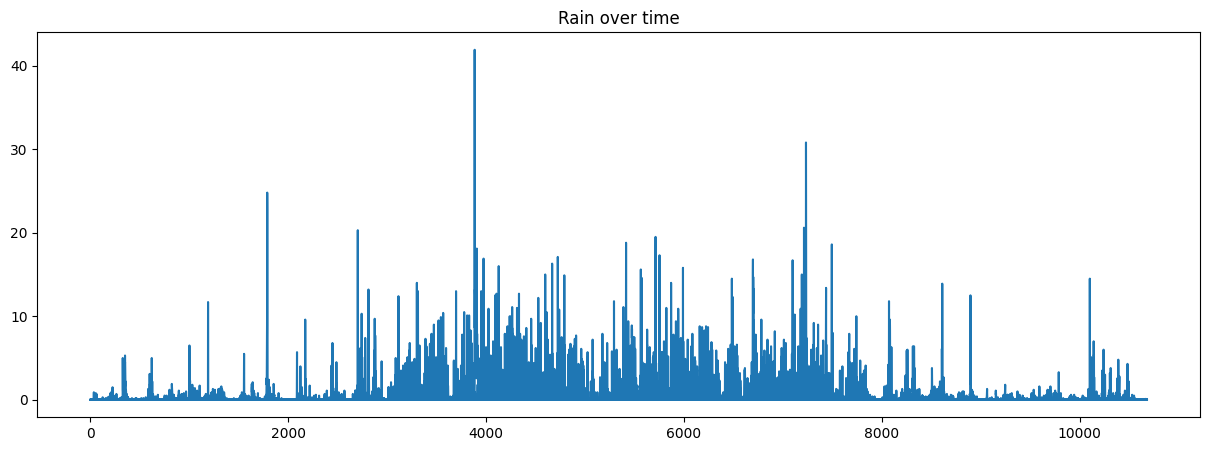

In [197]:
plt.figure(figsize=(15,5))
plt.plot(df.index, df['rain'])
plt.title("Rain over time")
plt.show()